In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
df = pd.read_csv("/content/iris (1).csv")

# Features and target
X = df.drop("species", axis=1)   # change column name if needed
y = df["species"]

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create KNN model (choose k=5 as a good default)
knn = KNeighborsClassifier(n_neighbors=5)

# Train model
knn.fit(X_train, y_train)

# Predictions
y_pred = knn.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
df = pd.read_csv("/content/diabetes.csv")

# Features and target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# KNN model (try k=5 or experiment)
knn = KNeighborsClassifier(n_neighbors=5)

# Train model
knn.fit(X_train_scaled, y_train)

# Predictions
y_pred = knn.predict(X_test_scaled)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.6948051948051948

Confusion Matrix:
 [[79 20]
 [27 28]]


Best K: 7


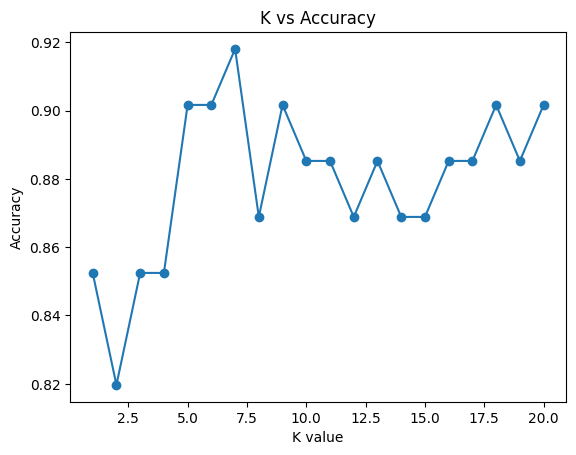

Accuracy: 0.9180327868852459


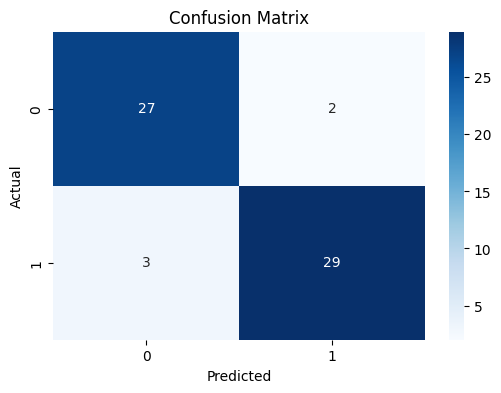


Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.93      0.92        29
           1       0.94      0.91      0.92        32

    accuracy                           0.92        61
   macro avg       0.92      0.92      0.92        61
weighted avg       0.92      0.92      0.92        61



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
df = pd.read_csv("/content/heart.csv")

# Features and target
X = df.drop("target", axis=1)
y = df["target"]

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling (VERY IMPORTANT for KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 🔷 Find best K
k_values = range(1, 21)
scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    scores.append(accuracy_score(y_test, y_pred))

# Best K
best_k = k_values[np.argmax(scores)]
print("Best K:", best_k)

# Plot K vs Accuracy
plt.plot(k_values, scores, marker='o')
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy")
plt.show()

# 🔷 Train final model with best K
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

# 🔷 Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# 🔷 Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 🔷 Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

In [4]:
X_train_scaled

array([[-1.35679832,  0.72250438,  0.00809909, ...,  0.95390513,
        -0.68970073, -0.50904773],
       [ 0.38508599,  0.72250438, -0.97189094, ...,  0.95390513,
        -0.68970073,  1.17848036],
       [-0.92132724,  0.72250438,  0.98808912, ..., -0.69498803,
        -0.68970073, -0.50904773],
       ...,
       [ 1.58263146,  0.72250438,  1.96807914, ..., -0.69498803,
         0.32186034, -0.50904773],
       [-0.92132724,  0.72250438, -0.97189094, ...,  0.95390513,
        -0.68970073,  1.17848036],
       [ 0.92942484, -1.38407465,  0.00809909, ...,  0.95390513,
         1.33342142, -0.50904773]])

Default RF Accuracy (10 trees): 1.0
Confusion Matrix (Default):
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Best Accuracy: 1.0
Best Number of Trees: 10

Confusion Matrix (Best Model):
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


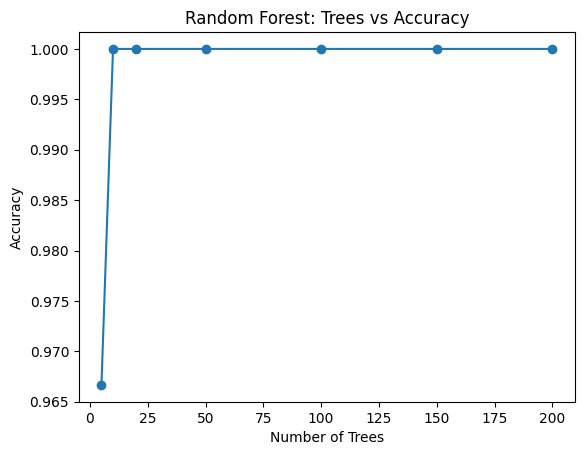

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
df = pd.read_csv("/content/iris (1).csv")

# Features and target
X = df.drop("species", axis=1)   # change if column name differs
y = df["species"]

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 🔷 1. Default Random Forest (n_estimators = 10)
rf_default = RandomForestClassifier(n_estimators=10, random_state=42)
rf_default.fit(X_train, y_train)

y_pred_default = rf_default.predict(X_test)

print("Default RF Accuracy (10 trees):", accuracy_score(y_test, y_pred_default))
print("Confusion Matrix (Default):\n", confusion_matrix(y_test, y_pred_default))


# 🔷 2. Tuning number of trees
tree_values = [5, 10, 20, 50, 100, 150, 200]
accuracy_list = []

for n in tree_values:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracy_list.append(acc)

# Find best
best_accuracy = max(accuracy_list)
best_trees = tree_values[accuracy_list.index(best_accuracy)]

print("\nBest Accuracy:", best_accuracy)
print("Best Number of Trees:", best_trees)

# Train final model with best trees
rf_best = RandomForestClassifier(n_estimators=best_trees, random_state=42)
rf_best.fit(X_train, y_train)

y_pred_best = rf_best.predict(X_test)

print("\nConfusion Matrix (Best Model):\n", confusion_matrix(y_test, y_pred_best))


# 🔷 Plot Trees vs Accuracy
plt.plot(tree_values, accuracy_list, marker='o')
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Random Forest: Trees vs Accuracy")
plt.show()